<a href="https://www.kaggle.com/code/sonawanelalitsunil/tmdb-top-rated-movies-dataset-ml?scriptVersionId=228469643" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/movies-dataset-tmdb-top-rated/top_rated_movies(tmdb).csv


## Title: TMDB Top-Rated Movies Dataset

#### Description: A dataset of top-rated movies from TMDB, including ratings, genres, release dates, and other key details. Ideal for analysis and recommendation system projects.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/movies-dataset-tmdb-top-rated/top_rated_movies(tmdb).csv')

In [3]:
df.head()

,id,title,overview,release_date,popularity,vote_average,vote_count
0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,1994-09-23,5.522,8.708,27883
1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,5.317,8.689,21151
2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,4.747,8.570,12771
3,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,4.457,8.567,16219
4,1356039,Counterattack,When a hostage rescue mission creates a new en...,2025-02-27,9.430,8.524,431


In [4]:
df.tail()

,id,title,overview,release_date,popularity,vote_average,vote_count
8555,291264,The Family Fang,A brother and sister return to their family ho...,2016-04-16,3.535,5.800,329
8556,250349,Barbecue,"On his 50th birthday, a man who's been watchin...",2014-04-30,3.829,5.834,699
8557,150202,The Haunting in Connecticut 2: Ghosts of Georgia,A young family moves into a historic home in G...,2013-02-01,3.533,5.800,520
8558,4942,Leatherheads,A light hearted comedy about the beginnings of...,2008-03-24,3.532,5.800,457
8559,748167,Uglies,In a futuristic dystopia with enforced beauty ...,2024-09-12,3.657,5.800,741


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8560 entries, 0 to 8559
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            8560 non-null   int64  
 1   title         8560 non-null   object 
 2   overview      8560 non-null   object 
 3   release_date  8558 non-null   object 
 4   popularity    8560 non-null   float64
 5   vote_average  8560 non-null   float64
 6   vote_count    8560 non-null   int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 468.2+ KB


In [6]:
df.describe()

,id,popularity,vote_average,vote_count
count,8.560000e+03,8560.000000,8560.000000,8560.000000
mean,2.082396e+05,3.721817,6.845229,2159.248715
std,2.768840e+05,0.770182,0.597392,3370.513826
min,2.000000e+00,0.003000,5.800000,300.000000
25%,1.001850e+04,3.533000,6.371000,480.000000
50%,3.686550e+04,3.557000,6.800000,903.000000
75%,3.861218e+05,3.817000,7.300000,2193.250000
max,1.356039e+06,29.661000,8.708000,37174.000000


In [7]:
df.isnull().sum()

id              0
title           0
overview        0
release_date    2
popularity      0
vote_average    0
vote_count      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(8560, 7)

In [10]:
df.corr

<bound method DataFrame.corr of            id                                             title  \
0         278                          The Shawshank Redemption   
1         238                                     The Godfather   
2         240                             The Godfather Part II   
3         424                                  Schindler's List   
4     1356039                                     Counterattack   
...       ...                                               ...   
8555   291264                                   The Family Fang   
8556   250349                                          Barbecue   
8557   150202  The Haunting in Connecticut 2: Ghosts of Georgia   
8558     4942                                      Leatherheads   
8559   748167                                            Uglies   

                                               overview release_date  \
0     Imprisoned in the 1940s for the double murder ...   1994-09-23   
1     Spanning the 

In [11]:
df.columns

Index(['id', 'title', 'overview', 'release_date', 'popularity', 'vote_average',
       'vote_count'],
      dtype='object')

## Data visualizations

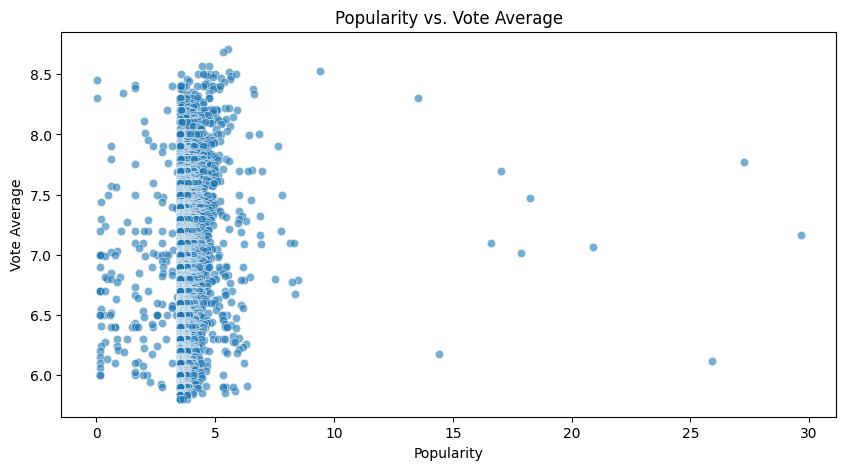

In [12]:
# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# 1. Popularity vs. Vote Average (Scatter Plot)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['popularity'], y=df['vote_average'], alpha=0.6)
plt.xlabel('Popularity')
plt.ylabel('Vote Average')
plt.title('Popularity vs. Vote Average')
plt.show()

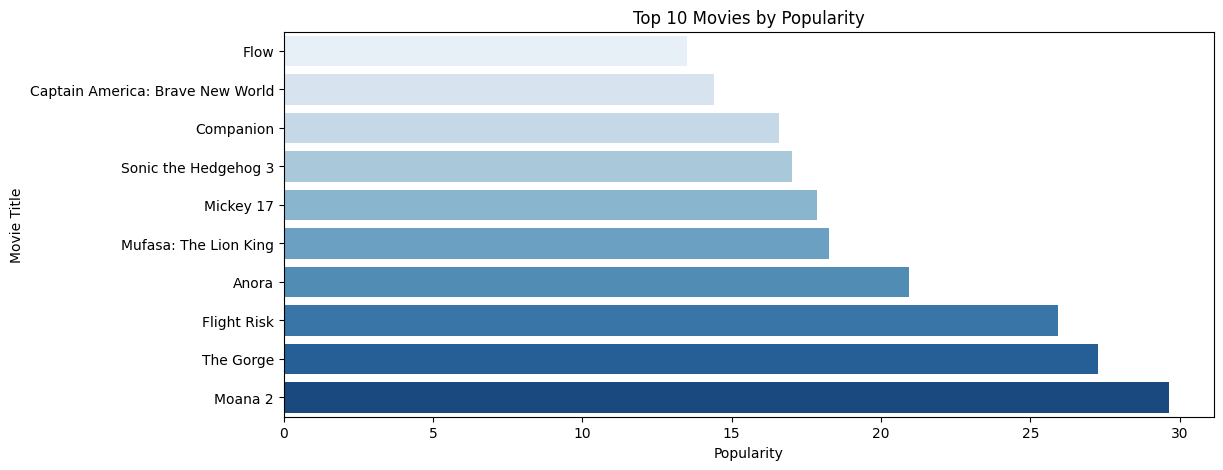

In [13]:
# 2. Top 10 Movies by Popularity (Bar Chart)
top_movies = df.nlargest(10, 'popularity')
plt.figure(figsize=(12, 5))
sns.barplot(y=top_movies['title'], x=top_movies['popularity'], palette='Blues_r')
plt.xlabel('Popularity')
plt.ylabel('Movie Title')
plt.title('Top 10 Movies by Popularity')
plt.gca().invert_yaxis()
plt.show()

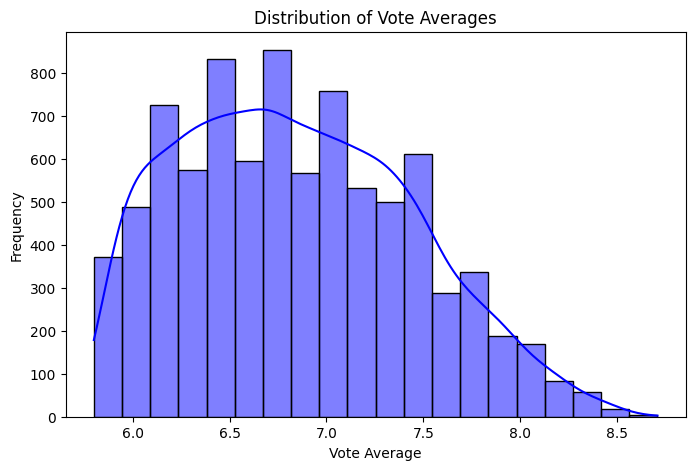

In [14]:
# 3. Distribution of Vote Average (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['vote_average'], bins=20, kde=True, color='blue')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.title('Distribution of Vote Averages')
plt.show()

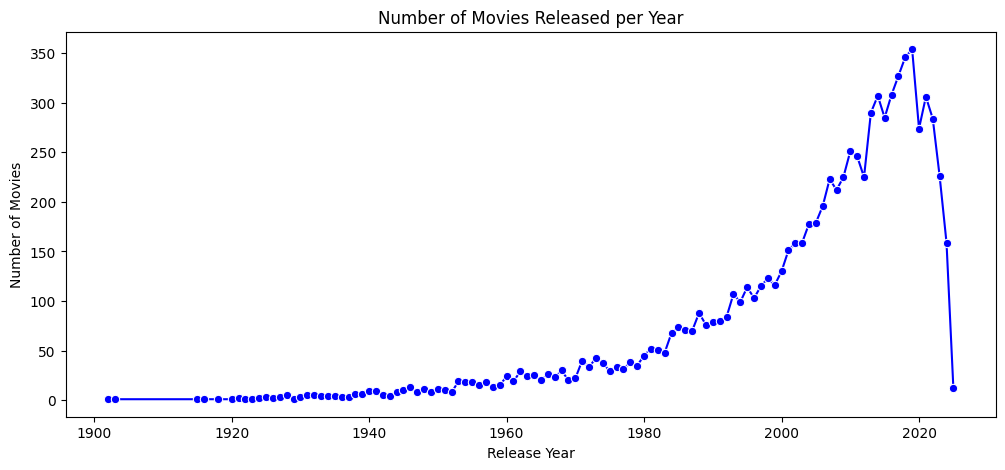

In [15]:
# 4. Number of Movies Released per Year (Line Chart)
year_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='blue')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.title('Number of Movies Released per Year')
plt.show()

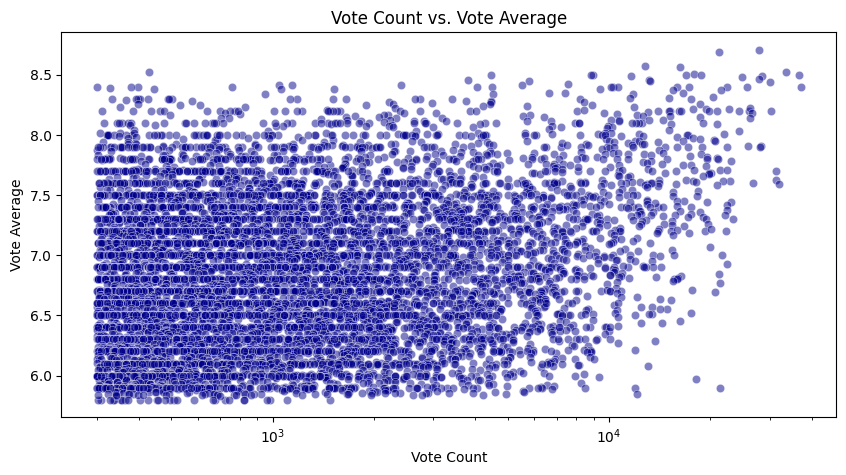

In [16]:
# 5. Vote Count vs. Vote Average (Scatter Plot)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['vote_count'], y=df['vote_average'], alpha=0.5, color='darkblue')
plt.xlabel('Vote Count')
plt.ylabel('Vote Average')
plt.title('Vote Count vs. Vote Average')
plt.xscale('log')  # Log scale to better visualize the spread
plt.show()

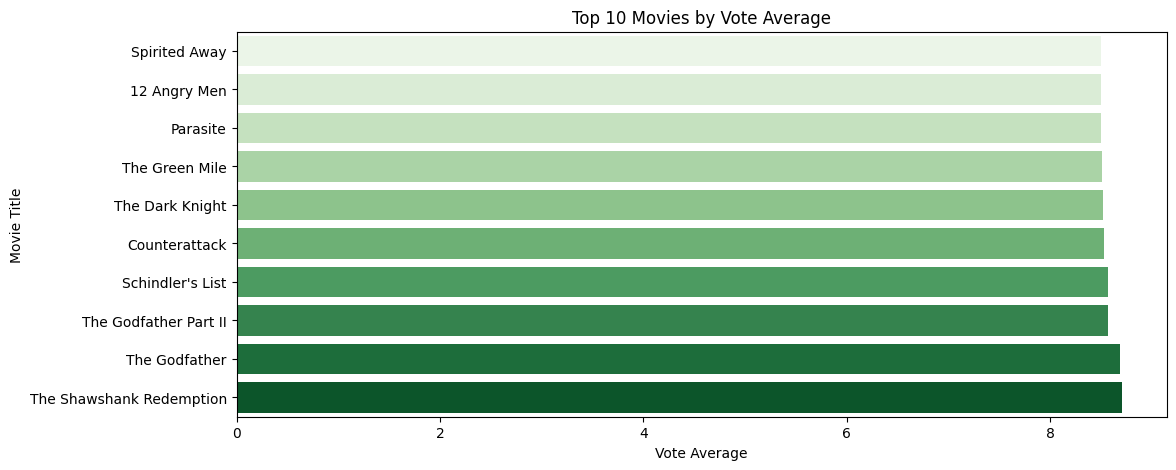

In [17]:
# 6. Top 10 Movies by Vote Average (Bar Chart)
top_rated_movies = df.nlargest(10, 'vote_average')
plt.figure(figsize=(12, 5))
sns.barplot(y=top_rated_movies['title'], x=top_rated_movies['vote_average'], palette='Greens_r')
plt.xlabel('Vote Average')
plt.ylabel('Movie Title')
plt.title('Top 10 Movies by Vote Average')
plt.gca().invert_yaxis()
plt.show()

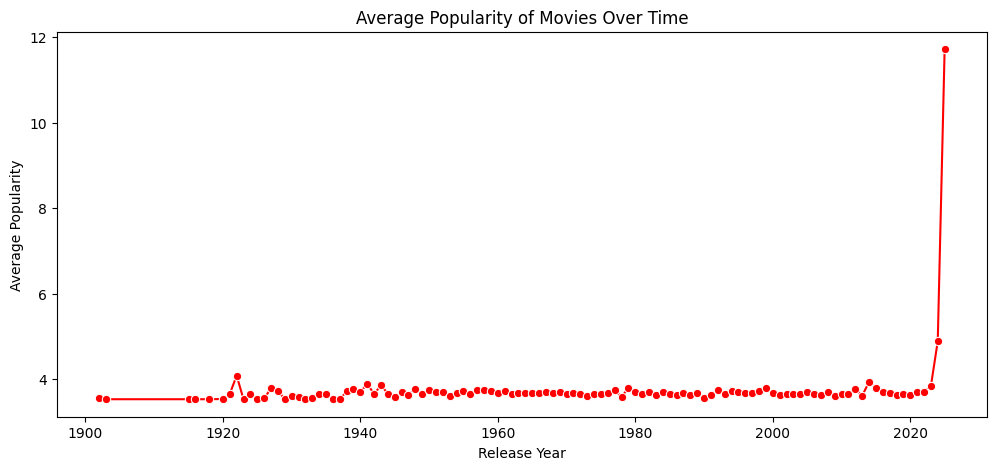

In [18]:
# 7. Popularity Over Time (Line Chart)
popularity_by_year = df.groupby('release_year')['popularity'].mean()
plt.figure(figsize=(12, 5))
sns.lineplot(x=popularity_by_year.index, y=popularity_by_year.values, marker='o', color='red')
plt.xlabel('Release Year')
plt.ylabel('Average Popularity')
plt.title('Average Popularity of Movies Over Time')
plt.show()

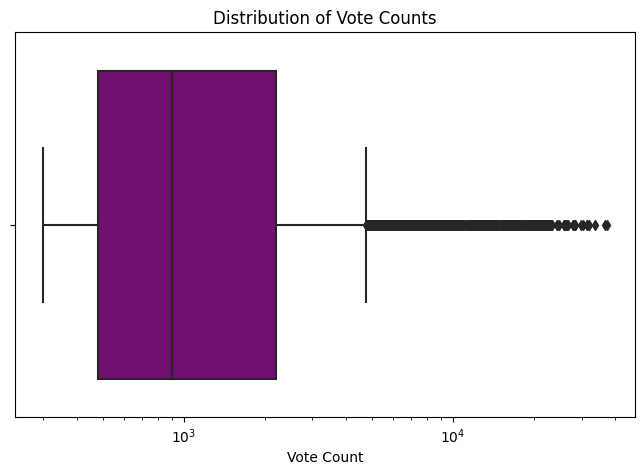

In [19]:
# 8. Vote Count Distribution (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['vote_count'], color='purple')
plt.xlabel('Vote Count')
plt.title('Distribution of Vote Counts')
plt.xscale('log')
plt.show()

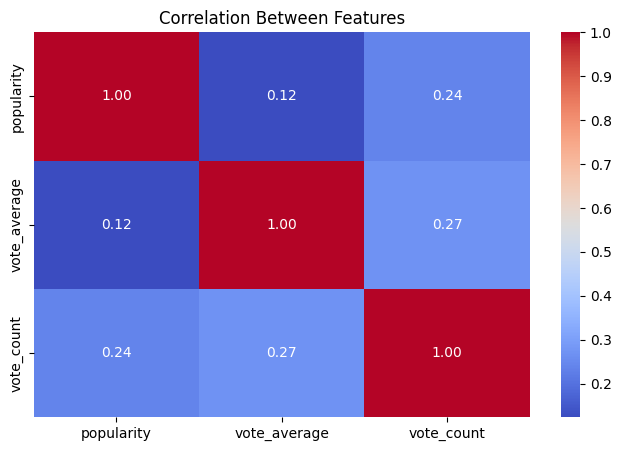

In [20]:
plt.figure(figsize=(8, 5))
corr = df[['popularity', 'vote_average', 'vote_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Features')
plt.show()

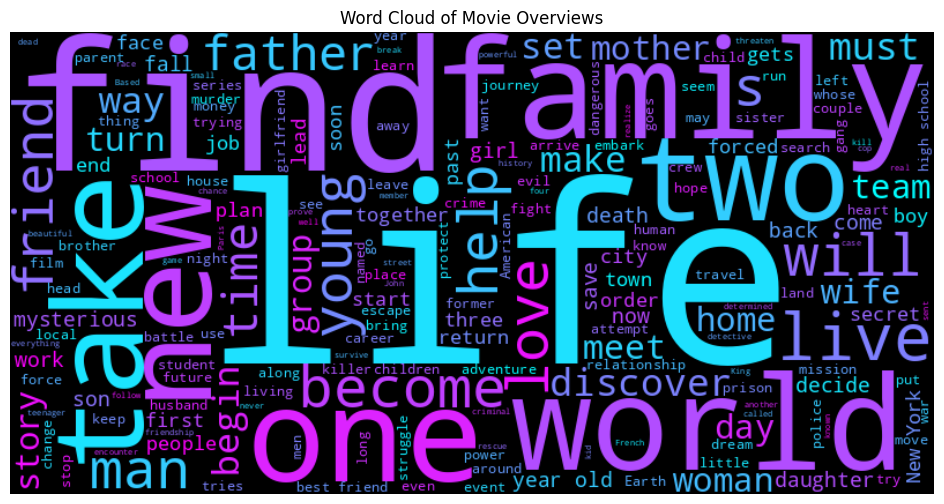

In [21]:
# 10. Popular Genres (Word Cloud)
from wordcloud import WordCloud
text = ' '.join(df['overview'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='cool').generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Overviews')
plt.show()

## predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [23]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

In [24]:
df.drop(columns=['id', 'release_date'], inplace=True)

In [25]:
# Label encode categorical features
le = LabelEncoder()
df['title'] = le.fit_transform(df['title'].astype(str))
df['overview'] = le.fit_transform(df['overview'].astype(str))

In [26]:
# Define features and target
X = df.drop(columns=['vote_average'])
y = df['vote_average']

In [27]:
from sklearn.impute import SimpleImputer

# Handle missing values
imputer = SimpleImputer(strategy="median")  # Use 'mean' or 'most_frequent' if preferred
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [28]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [30]:
# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} MAE: {mae:.4f}")

Linear Regression MAE: 0.4628
Random Forest MAE: 0.4413
Gradient Boosting MAE: 0.4363


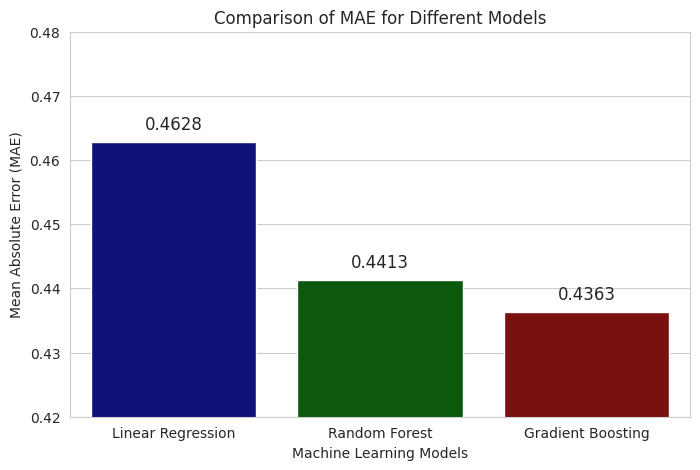

In [31]:
models = ["Linear Regression", "Random Forest", "Gradient Boosting"]
mae_scores = [0.4628, 0.4413, 0.4363]

# Set style
sns.set_style("whitegrid")

# Create bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=mae_scores, palette=["darkblue", "darkgreen", "darkred"])

# Add labels and title
plt.xlabel("Machine Learning Models")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Comparison of MAE for Different Models")

# Display values on bars
for i, v in enumerate(mae_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=12)

plt.ylim(0.42, 0.48)  # Adjust y-axis for better visibility
plt.show()


## Thank you!!!!...pls upvote!!!!